In [1]:
import anndata
import numpy as np
from readcount_tools import readcount_pipeline, umi_pipeline, scanpy_preproc_baseline

from readcount_tools import PAPER_CONTEXT, PAGEWIDTH_IN, POINTSIZE_HIGHLIGHT,POINTSIZE_SMALL,SMALL_SIZE,MEDIUM_SIZE,BIGGER_SIZE,LINEWIDTH,POINTSIZE,TICKLENGTH,LEGEND_FONTSIZE,SPINEWIDTH,LETTER_LOC_X,LETTER_LOC_Y
import matplotlib as mpl

import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
%%time
#30sec
adata_qumi_census_readcounts = anndata.read_h5ad('data/tasic/adata_qumi_census.h5ad')
adata_qumi_census_readcounts.var_names_make_unique()

tcmalloc: large alloc 1545371648 bytes == 0x64848000 @ 
tcmalloc: large alloc 1545371648 bytes == 0xef376000 @ 
tcmalloc: large alloc 1545371648 bytes == 0x179cf8000 @ 
tcmalloc: large alloc 5305827328 bytes == 0x204984000 @ 


CPU times: user 1.52 s, sys: 7.35 s, total: 8.86 s
Wall time: 52 s


/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/usr/local/lib/python3.8/dist-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
adata_qumi_census_readcounts.layers

Layers with keys: census, qumis, readcounts, tpm

In [4]:
adata_qumis = adata_qumi_census_readcounts.copy()
adata_qumis.X = adata_qumi_census_readcounts.layers['qumis'].copy()
del adata_qumis.layers

adata_census = adata_qumi_census_readcounts.copy()
adata_census.X = adata_qumi_census_readcounts.layers['census'].copy()
del adata_census.layers

adata_readcounts = adata_qumi_census_readcounts.copy()
adata_readcounts.X = adata_qumi_census_readcounts.layers['readcounts'].copy()
del adata_readcounts.layers

adata_readcount_umi_processing = adata_readcounts.copy()
adata_readcount_scanpy_in = adata_readcounts.copy()

tcmalloc: large alloc 5305827328 bytes == 0x4e2b90000 @ 
tcmalloc: large alloc 5305827328 bytes == 0x4b4aac000 @ 
tcmalloc: large alloc 5305827328 bytes == 0x4b4aac000 @ 


In [5]:
n_hvgs=3000
n_comps=1000

In [6]:
%%time
#compound residuals
hvg_adata_readcounts, adata_readcounts =  readcount_pipeline(adata_readcounts,
                                                             alpha=50,theta=100, n_hvgs=n_hvgs,n_comps=n_comps,
                                                             return_full_hvg_results=True,run_tsne=False)
#umi residuals (=compound residuals with alpha=1)
hvg_adata_readcount_umi_processing, adata_readcount_umi_processing =  readcount_pipeline(adata_readcount_umi_processing,
                                                                                         alpha=1,theta=100, n_hvgs=n_hvgs,n_comps=n_comps,
                                                                                         return_full_hvg_results=True,run_tsne=False)
#scanpy
adata_readcounts_scanpy_out,hvg_readcounts_scanpy = scanpy_preproc_baseline(adata_readcount_scanpy_in,
                                                                            n_hvgs=n_hvgs,n_comps=n_comps,
                                                                            return_full_hvg_results=True,run_tsne=False)
#qumis+scanpy
adata_qumis_scanpy,hvg_qumis_scanpy = scanpy_preproc_baseline(adata_qumis,
                                                              n_hvgs=n_hvgs,n_comps=n_comps,
                                                              return_full_hvg_results=True,run_tsne=False)
#census+scanpy
adata_census_scanpy,hvg_census_scanpy = scanpy_preproc_baseline(adata_census,
                                                                n_hvgs=n_hvgs,n_comps=n_comps,
                                                                return_full_hvg_results=True,run_tsne=False)

pr_theta100_alpha50.0


tcmalloc: large alloc 4811669504 bytes == 0x876b2c000 @ 
tcmalloc: large alloc 4811669504 bytes == 0x995ff0000 @ 
tcmalloc: large alloc 4811669504 bytes == 0xab4cb4000 @ 
tcmalloc: large alloc 4811669504 bytes == 0x995ff0000 @ 
tcmalloc: large alloc 4811669504 bytes == 0xbd4178000 @ 
tcmalloc: large alloc 4811669504 bytes == 0xcf2e3c000 @ 


pr_theta100_alpha50.0_afterHVG
pr_theta100_alpha1.0
pr_theta100_alpha1.0_afterHVG
CPU times: user 17min 49s, sys: 6min 13s, total: 24min 3s
Wall time: 2min 14s


### Supplementary Figure S10

In [7]:
readcounts_df = pd.DataFrame( dict(means=adata_readcounts.var['mean_counts_allCells'],
                           criterion=adata_readcounts.var['pr_theta100_alpha50.0_var'],
                           marker=adata_readcounts.var.marker_idx.values))

umi_residuals_df = pd.DataFrame( dict(means=adata_readcount_umi_processing.var['mean_counts_allCells'],
                           criterion=adata_readcount_umi_processing.var['pr_theta100_alpha1.0_var'],
                           marker=adata_readcount_umi_processing.var.marker_idx.values))

census_df = pd.DataFrame( dict(means=adata_census.var['mean_counts_allCells'].values,
                           criterion=hvg_census_scanpy['dispersions_norm'],
                              marker=adata_census.var.marker_idx.values))

qumi_df = pd.DataFrame( dict(means=adata_qumis.var['mean_counts_allCells'].values,
                           criterion=hvg_qumis_scanpy['dispersions_norm'],
                            marker=adata_qumis.var.marker_idx.values))

scanpy_df = pd.DataFrame( dict(means=adata_readcount_scanpy_in.var['mean_counts_allCells'].values,
                           criterion=hvg_readcounts_scanpy['dispersions_norm'],
                            marker=adata_readcount_scanpy_in.var.marker_idx.values))

Compound Residuals 14
UMI Residuals 12
Scanpy defaults 12
qUMI + Scanpy 10
Census + Scanpy 11


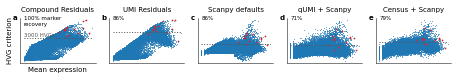

In [8]:
ncols = 5
nrows = 1
panelsize_square_in = PAGEWIDTH_IN/ncols
panelheight_resvar_in = panelsize_square_in/1.5
figheight_in = panelheight_resvar_in*1.2

path='figures/S_tasic_hetero_method_comparison.pdf'

with mpl.rc_context(PAPER_CONTEXT):

    fig,axes_resvar = plt.subplots(nrows=1,ncols=5,figsize=(PAGEWIDTH_IN,figheight_in),layout='constrained')


    
    for i,(ax,df,xlab,title) in enumerate(zip(axes_resvar,
                    [readcounts_df, umi_residuals_df, scanpy_df, qumi_df, census_df,],
                    ['Mean expression']+['']*4,
                    ['Compound Residuals','UMI Residuals','Scanpy defaults','qUMI + Scanpy', 'Census + Scanpy'])):
        
        ax.scatter(df.means,df.criterion,s=POINTSIZE_SMALL,lw=0,rasterized=True)
        ax.scatter(df.means[df.marker],df.criterion[df.marker],s=POINTSIZE_HIGHLIGHT,lw=0,c='tab:red',rasterized=True)
        ax.set_title(title)
        ax.set_xscale('log')
        
        #compute percentage of markers among the top 3000 HVGs
        n_markers = sum(df.marker)
        criterion = df.criterion.values
        criterion_marker = criterion[df.marker.values]        
        topn_criterion = criterion[np.argsort(-criterion)[3000]]
        ax.hlines(y=topn_criterion,xmin=min(df.means),xmax=max(df.means),lw=LINEWIDTH,color='#555555',linestyles=':')
        
        marker_in_topn = criterion_marker > topn_criterion
        print(title, sum(marker_in_topn))
        marker_recovered = int(np.round(sum(marker_in_topn)/n_markers,decimals=2)*100)
        if i==0:
            performancelabeltext=' marker\nrecovery'
            ax.set_xlabel('Mean expression')
            ax.text(x=min(df.means),y=topn_criterion,s='3000 HVGs',fontsize=LEGEND_FONTSIZE,va='bottom',color='#555555')
        else:
            performancelabeltext=''
        ax.text(0.05,1.05,f'{marker_recovered}%{performancelabeltext}',fontsize=LEGEND_FONTSIZE,transform=ax.transAxes,va='top')
    
        #linear scale for normalized dispersion (scanpy HVG criterion)
        if 'Scanpy' in title:
            ax.set_yscale('linear')
            ax.set_yticks([])
        #log scale for residual variance
        else:
            ax.set_yscale('log')
            ax.set_yticks([])
        
        ax.set_xlabel(xlab)
        if i==0:
            ax.set_ylabel('HVG criterion',labelpad=7)
        
        ax.minorticks_off()
        ax.set_xticks([])    
    sns.despine()
    
    for ax in axes_resvar:
        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(SPINEWIDTH)
    
    letters=['a','b','c','d','e']
    for ax,letter, in zip(axes_resvar,letters):
        ax.text(LETTER_LOC_X+0.2,LETTER_LOC_Y+0,letter,transform=ax.transAxes,fontweight='bold')

    
    fig.savefig(path, dpi=300, format=None,pad_inches=0)